In [1]:
using Pkg

ROOT = abspath(joinpath(@__DIR__, ".."))
Pkg.activate(ROOT)

using PulsePropagation
using FFTW
using LinearAlgebra
using PyPlot
using DelimitedFiles

  Activating project at `~/FastDifferentiableMMNLO`


In [2]:
c_light = 2.99792458e-4; # m/ps -- see manual for unit system info
Nt = 2^15;
time_window = 100; # ps
λ0 = 1550e-9; # m
ω0 = 2*π*c_light/λ0;
f0 = ω0 / (2*π)

dofs = degrees_of_freedom(:time);
grid = TimeGrid(Nt, time_window);
domain = MMGNLSEDomain(dofs,grid);

## Useful helpers
t = time_axis(grid);
Ω = frequency_axis(grid);
f = f0 .+ Ω/(2*π);
λ = (c_light ./ f);
λ_nm = λ * 1e9;

In [3]:
## SMF specification
material = Silica(raman=AgarwalRaman());
mfd = 9.2e-6; # mode-field diameter.
Aeff= π * (mfd / 2)^2;
gamma = (material.n2)*(2*π/λ0)*(1/Aeff);

fiber_length = 250;

beta2 = -2.06e-26 * 1e24;
betas = reshape([0.0, 0.0, beta2], :, 1);


## Initial field, N=1 soliton
pulse_fwhm = 4;
tau_sech = 4 / (2*acosh(sqrt(2)));
L_disp = tau_sech^2 / abs(beta2);

peak_power = abs(beta2 * 1e-24) / (gamma) / (tau_sech * 1e-12)^2;

initial_field = zeros(Nt,1,1); 
initial_field[:,1,1] = sqrt(peak_power) * sech.(t/tau_sech);

In [4]:
parameters = MMGNLSEParameters(domain; length = fiber_length, beta = TaylorBeta(betas), S = 1/Aeff, n2 = material.n2, omega0 = ω0, raman=AgarwalRaman())

MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, SpatialOverlap{Float64}, Float64, Float64, AgarwalRaman{Float64}}(MMGNLSEDomain{TimeGrid{Float64}}(DegreesOfFreedom(:time), TimeGrid{Float64}(32768, 0.0030517578125)), 250.0, [0;;;;], [0;;;;], TaylorBeta{Float64, 2}([0.0; 0.0; -0.0206;;]), SpatialOverlap{Float64}([1.5043000292239635e10;;;;]), 2.3e-20, 1215.2590756831312, AgarwalRaman{Float64}(0.18, 0.0122, 0.032))

In [5]:
Δz = L_disp / 25;

solution = solve_mmgnlse(initial_field, parameters, Δz);
At = get_temporal_field(solution);
Aω = get_spectral_field(solution);


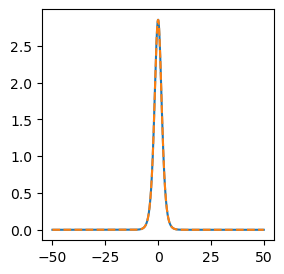

In [6]:
figure(figsize=(3,3))
plot(t, abs2.(initial_field[:,1,1]))
plot(t, abs2.(At[:,1,1]),"--")
display(gcf())

In [7]:
# obs = TemporalMoment(); # computes pulse center of gravity
# lambda_L = terminal_condition(obs, solution);

# dz_adjoint = Δz;
# adjoint = solve_adjoint(lambda_L, parameters, dz_adjoint; forward_solution=solution, saveat=Δz);

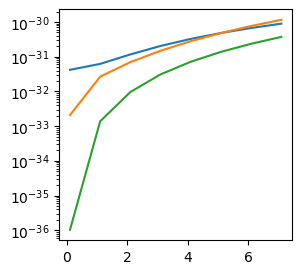

In [8]:
z_list = [0.1:1:8;]*L_disp;

gain = 0.001;
tau_sech_s = tau_sech * 1e-12;

kb = 1.38e-23;
temperature = 300;
hbar = 1.05e-34;

tau1_raman_fs = 12.2;
tau2_raman_fs = 32;
f_raman = 0.18

dt = diff(t)[1]
n0 = sum(abs2.(At)*dt * 1e-12) / (hbar * ω0 * 1e12);

F0 = 2 * kb * temperature / hbar *
     (tau2_raman_fs * 1e-15) /
     (1 + tau2_raman_fs^2 / tau1_raman_fs^2) *
     f_raman

t_vac = zero(z_list);
t_gh = zero(z_list);
t_raman = zero(z_list);

t_vac_drummond = zero(z_list);
t_gh_drummond = zero(z_list);
t_raman_drummond = zero(z_list);

Cω = PulsePropagation.raman_langevin_spectrum(
    Nt, diff(t)[1], f0, gamma;
    raman_fraction=0.18,
    temperature_K=300.0,
);

Cω = fftshift(Cω)

for ii = 1:length(z_list)
    L_fiber = z_list[ii];
    t_vac_drummond[ii] = (tau_sech_s)^2 * ((π^2)/12 + 1/3 *(L_fiber/L_disp)^2) / n0

    t_gh_d_lin = (tau_sech_s)^2 * ((gain) * 2 * π^2 / 12 / n0) * (1/L_disp)^1 * L_disp .* (L_fiber).^1;
    t_gh_d_cubic = (tau_sech_s)^2 * ((gain) * 2 / 9 / n0) * (1/L_disp)^3 * L_disp .* (L_fiber).^3;
    t_gh_drummond[ii] = t_gh_d_lin + t_gh_d_cubic;

    
    t_raman_drummond[ii] = (16/45)*(tau_sech_s)^2 * (F0) .* (L_fiber/L_disp).^3 / (n0)
end

figure(figsize=(3,3))
semilogy(z_list/L_disp,t_vac_drummond)
semilogy(z_list/L_disp,t_gh_drummond)
semilogy(z_list/L_disp,t_raman_drummond)
display(gcf())

In [9]:
Nz = 201;
for ii = 1:length(z_list)
    L_fiber = z_list[ii];
    
    # system instantiation
    parameters = MMGNLSEParameters(domain; length = L_fiber, beta = TaylorBeta(betas), S = 1/Aeff, n2 = material.n2, omega0 = ω0, raman=AgarwalRaman())
    
    dz_forward = L_fiber / Nz;
    solution = solve_mmgnlse(initial_field, parameters, dz_forward; saveat = dz_forward);

    # observable
    
    obs = TemporalMoment(); # computes pulse center of gravity
    lambda_L = terminal_condition(obs, solution);

    dz_adjoint = dz_forward;
    adjoint = solve_adjoint(lambda_L, parameters, dz_adjoint; forward_solution=solution, saveat=dz_adjoint)
    jitter_spectral_sensitivity_final = get_spectral_field(adjoint; units=:photon)[:,:,1];
    jitter_spectral_sensitivity_trajectory = get_spectral_field(adjoint; z=:all, units=:photon);
    
    # Vacuum fluctuation contribution
    t_vac[ii] = sum(abs2.(jitter_spectral_sensitivity_final)) * 1e-24;    

    # Gordon-Haus contribution
    t_gh[ii] = 2*gain*(sum(abs2.(jitter_spectral_sensitivity_trajectory))) * 1e-24 * dz_adjoint #2 is for gain+loss noise;

    # Raman contribution
    Azt = get_temporal_field(solution; z=:all, units=:power);
    λzt = conj(get_temporal_field(adjoint; z=:all, units=:power));
    Bzt = -2*imag(Azt .* λzt);
    Bzω = fftshift(ifft(Bzt,1),1);
    t_raman[ii] = gamma^2 * sum(abs2.(Bzω) .* Cω) * (diff(f)[1] * 1e12) * dz_adjoint * 1e-24;
    
end

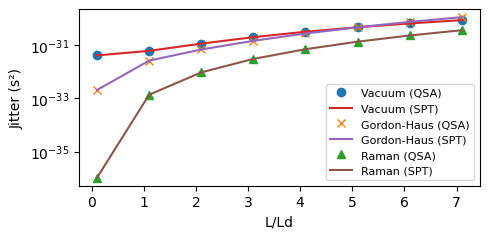

In [10]:
figure(figsize=(5,2.5))

vac_qsa, = semilogy(z_list / L_disp,t_vac,"o")
gh_qsa, = semilogy(z_list / L_disp,t_gh,"x")
raman_qsa, = semilogy(z_list / L_disp,t_raman,"^")

vac_spt, = semilogy(z_list / L_disp,t_vac_drummond)
gh_spt, = semilogy(z_list / L_disp,t_gh_drummond)
raman_spt, = semilogy(z_list / L_disp,t_raman_drummond)

xlabel("L/Ld")
ylabel("Jitter (s²)")
legend([vac_qsa, vac_spt, gh_qsa, gh_spt, raman_qsa, raman_spt],
       ["Vacuum (QSA)", "Vacuum (SPT)", "Gordon-Haus (QSA)", "Gordon-Haus (SPT)", "Raman (QSA)", "Raman (SPT)"],
       loc="lower right",  fontsize=8)
tight_layout()

display(gcf())